# Benchmark of Example 3: backends and time-domain route

This notebook reports the cost of the fifth-order 2Q calculation of `examples/example3_chi5_2q.ipynb`. The measurements come from scripts in `validation/benchmarks/scripts/`, which write JSON files to `validation/results/data/`; this notebook reads those files. In this notebook you will:

- compare the dense and the sparse backend on the seven pathways;
- compare the frequency-domain map with a time-sampled calculation followed by a Fourier transform, at two broadenings;
- read the estimated cost of the same map with the original QuDPy.

Timings were taken on one core of a laptop processor (BLAS limited to one thread), so they show scaling, not optimized performance. To measure again on your machine, set `rerun = True` in the next cell (a few minutes).

## 0. Imports and options

`run_script` launches one benchmark script with a single BLAS thread. It does nothing unless `rerun` is `True`. The time-domain comparison with QuDPy also needs a clone of `SilvaScience/QuDPy` (set `QUDPY_REPO` or place it next to this repository).

In [1]:
import json
import os
import subprocess
import sys
from pathlib import Path

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np

from models import ANALYSIS_FIGURES, DATA, results_dirs

results_dirs()
SCRIPTS = Path("scripts")
rerun = False          # True: run the scripts below


def run_script(name, *args):
    if not rerun:
        return
    env = dict(os.environ, OMP_NUM_THREADS="1", OPENBLAS_NUM_THREADS="1", MKL_NUM_THREADS="1")
    subprocess.run([sys.executable, str(SCRIPTS / name), *args], check=True, env=env)


def load(name):
    return json.loads((DATA / name).read_text())

## 1. Dense versus sparse backend

Script `bench_example3_dense_sparse.py` computes the model of the example ($D=10$, 7 pathways, $\eta=8$ meV) with both backends on a $31\times31$ grid over the same window, including the two mode-resolved polarizations.

In [2]:
run_script("bench_example3_dense_sparse.py")
ds = load("example3_dense_sparse.json")

print(f"D = {ds['D']}, {ds['pathways']} pathways, grid {ds['grid']}, eta = {ds['eta']} eV")
print(f"time: dense {ds['time_dense_s']:.1f} s, sparse {ds['time_sparse_s']:.1f} s")
for name, value in ds["relative_difference"].items():
    print(f"  {name}: max|dense - sparse| / max|dense| = {value:.1e}")
assert max(ds["relative_difference"].values()) < 1e-10

D = 10, 7 pathways, grid [31, 31], eta = 0.008 eV
time: dense 2.0 s, sparse 15.6 s
  polarization_h: max|dense - sparse| / max|dense| = 2.5e-14
  polarization_l: max|dense - sparse| / max|dense| = 2.6e-14


For $D=10$ the dense backend is faster, as for Example 1; the two agree to $\sim10^{-14}$.

## 2. Frequency domain versus time sampling

Script `bench_time_fft_ex3.py` evaluates the $151\times151$ map by sampling the fifth-order response in time and transforming it, for the smallest sampling that reaches a relative error of $10^{-2}$ and $10^{-3}$ with respect to the frequency-domain result, at $\eta=8$ meV and $\eta=2$ meV. For the original QuDPy it runs a small pilot (75 samples per axis) and extrapolates the time and the memory of the full map, instead of running it.

    eta  target  N per axis  time route (s)  frequency (s)  QuDPy est. (s)  QuDPy est. (GB)
   8meV    0.01        1080            19.8           38.6             937              7.4
   8meV   0.001        1620            43.8           38.6            1942              8.5
   2meV    0.01        4318           316.3           41.2           15224            160.8
   2meV   0.001        6477           712.4           41.2           32112            737.6


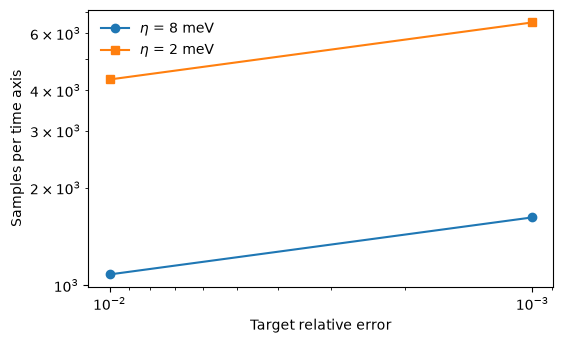

In [3]:
run_script("bench_time_fft_ex3.py")
tf = load("time_fft_ex3.json")

print(f"{'eta':>7}{'target':>8}{'N per axis':>12}{'time route (s)':>16}{'frequency (s)':>15}{'QuDPy est. (s)':>16}{'QuDPy est. (GB)':>17}")
for regime, report in tf.items():
    for target, best in report["time_route"].items():
        q = report["qudpy"][target]
        print(f"{regime:>7}{target:>8}{best['N_per_axis']:>12}{best['time_s']:>16.1f}{report['reference_time_s']:>15.1f}"
              f"{q['estimated_time_s']:>16.0f}{q['estimated_peak_GB']:>17.1f}")

fig, ax = plt.subplots(figsize=(6.0, 3.6))
for regime, marker in (("8meV", "o"), ("2meV", "s")):
    report = tf[regime]
    targets = list(report["time_route"])
    ax.loglog([float(t) for t in targets], [report["time_route"][t]["N_per_axis"] for t in targets], marker + "-", label=f"$\\eta$ = {regime[:-3]} meV")
ax.set_xlabel("Target relative error")
ax.set_ylabel("Samples per time axis")
ax.invert_xaxis()
ax.legend(frameon=False)
fig.savefig(ANALYSIS_FIGURES / "example3_benchmark_time_route.pdf", bbox_inches="tight")
plt.show()

The time route needs thousands of samples per axis at $\eta=2$ meV and its cost grows as the broadening decreases, whereas the frequency-domain map costs about 40 s at both broadenings. The extrapolated cost of the original QuDPy is thousands of seconds and several GB of memory, which is why the full map was not run with it. (Its `coherence2d` also fails with QuTiP 5 when a fixed delay precedes the first scan, as in this example.)

## Summary

- For $D=10$ the dense backend is faster than the sparse one, and they agree to $\sim10^{-14}$.
- The frequency-domain map costs about 40 s at both broadenings; a time-sampled route costs about as much at 8 meV and several times more at 2 meV.
- The original QuDPy is estimated at thousands of seconds and several GB for this map.